# Problem 1 — Steam Turbine Optimization (var1)
**Polynomial Regression from Scratch (NumPy)**

This notebook is the single entrypoint. Change parameters in the cells below or in the individual `.py` modules, then re-run.

| Module | Role |
|---|---|
| `data_loader.py` | Load CSVs, train/val split |
| `model.py` | Feature expansion + Normal Equation |
| `evaluate.py` | MSE, RMSE, R², MAE |
| `train.py` | Training loop + degree sweep |
| `predict.py` | Inference on test set |


In [9]:
!pwd
!ls

/content/drive/MyDrive/Assss1/ML-Assignment1/problem1
data_loader.py	model.py    problem1.ipynb  smoke_test.py
evaluate.py	predict.py  __pycache__     train.py


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import sys
sys.path.append('/content/drive/MyDrive/Assss1/ML-Assignment1/problem1')

import data_loader
import model as M
import evaluate as E
import train as T
import predict as P

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'font.size': 11,
})

---
## 1 · Load Data
All parameters are inherited from `data_loader.py`. Override them here if needed.

In [17]:
# ── Override any data_loader parameters here ────────────────────────────────
# e.g. to try all 6 features, change: features=["x1","x2","x3","x4","x5","x6"]

X_train, y_train, X_val, y_val, X_test, feature_names = data_loader.load_data(
    train_csv   = "/content/drive/MyDrive/Assss1/ML-Assignment1/IMT2024045/IMT2024045_train_var1.csv",
    test_csv    = "/content/drive/MyDrive/Assss1/ML-Assignment1/IMT2024045/IMT2024045_test_var1.csv",
    features    = data_loader.FEATURES,      # ["x1", "x2", "x3"]
    target      = data_loader.TARGET,
    val_ratio   = data_loader.VAL_RATIO,     # 0.20
    random_seed = data_loader.RANDOM_SEED,   # 42
)

[data_loader] Training   : 800 samples
[data_loader] Validation : 200   samples
[data_loader] Test       : 1000  samples
[data_loader] Features   : ['x1', 'x2', 'x3']


---
## 2 · Quick Data Exploration

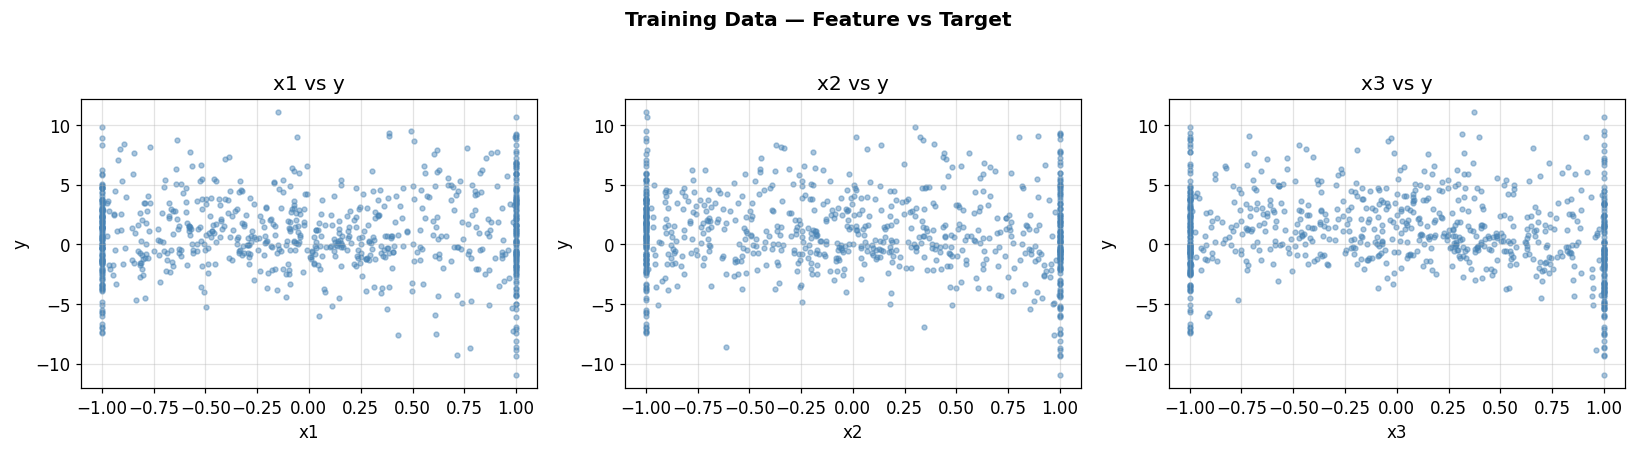

y  →  min=-10.960  max=11.111  mean=0.953  std=3.334


In [18]:
fig, axes = plt.subplots(1, len(feature_names), figsize=(5 * len(feature_names), 4))
if len(feature_names) == 1:
    axes = [axes]

for ax, fname, col in zip(axes, feature_names, X_train.T):
    ax.scatter(col, y_train, s=10, alpha=0.45, color='steelblue')
    ax.set_xlabel(fname)
    ax.set_ylabel('y')
    ax.set_title(f'{fname} vs y')

plt.suptitle('Training Data — Feature vs Target', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"y  →  min={y_train.min():.3f}  max={y_train.max():.3f}  "
      f"mean={y_train.mean():.3f}  std={y_train.std():.3f}")

---
## 3 · Degree Sweep — Finding the Optimal Degree
Train models for degrees `DEGREE_MIN` through `DEGREE_MAX` and compare Train vs Val metrics.

In [19]:
# ── Override degree range here if needed ────────────────────────────────────
DEGREE_MIN = T.DEGREE_MIN   # 1
DEGREE_MAX = T.DEGREE_MAX   # 8

results = T.sweep_degrees(
    X_train, y_train, X_val, y_val,
    degree_min   = DEGREE_MIN,
    degree_max   = DEGREE_MAX,
    feature_names = feature_names,
)

degrees    = [r['degree']    for r in results]
train_mse  = [r['train_mse'] for r in results]
val_mse    = [r['val_mse']   for r in results]
train_r2   = [r['train_r2']  for r in results]
val_r2     = [r['val_r2']    for r in results]
train_rmse = [r['train_rmse']for r in results]
val_rmse   = [r['val_rmse']  for r in results]

print("\nDegree sweep complete.")

MSE=10.646669  RMSE=3.262923  R²=0.042216  MAE=2.515288
MSE=11.691519  RMSE=3.419286  R²=-0.005036  MAE=2.629734
MSE=9.005477  RMSE=3.000913  R²=0.189859  MAE=2.374633
MSE=10.232363  RMSE=3.198807  R²=0.120398  MAE=2.604880
MSE=8.730240  RMSE=2.954698  R²=0.214620  MAE=2.341573
MSE=10.087348  RMSE=3.176059  R²=0.132863  MAE=2.607828
MSE=8.430348  RMSE=2.903506  R²=0.241599  MAE=2.286740
MSE=9.945339  RMSE=3.153623  R²=0.145071  MAE=2.571470
MSE=8.130887  RMSE=2.851471  R²=0.268538  MAE=2.236751
MSE=9.834306  RMSE=3.135970  R²=0.154616  MAE=2.531077
MSE=7.854369  RMSE=2.802565  R²=0.293414  MAE=2.202017
MSE=10.409051  RMSE=3.226306  R²=0.105209  MAE=2.559430
MSE=7.319580  RMSE=2.705472  R²=0.341524  MAE=2.107935
MSE=11.801139  RMSE=3.435279  R²=-0.014459  MAE=2.688837
MSE=6.885615  RMSE=2.624046  R²=0.380564  MAE=2.037226
MSE=12.707172  RMSE=3.564712  R²=-0.092344  MAE=2.761433

Degree sweep complete.


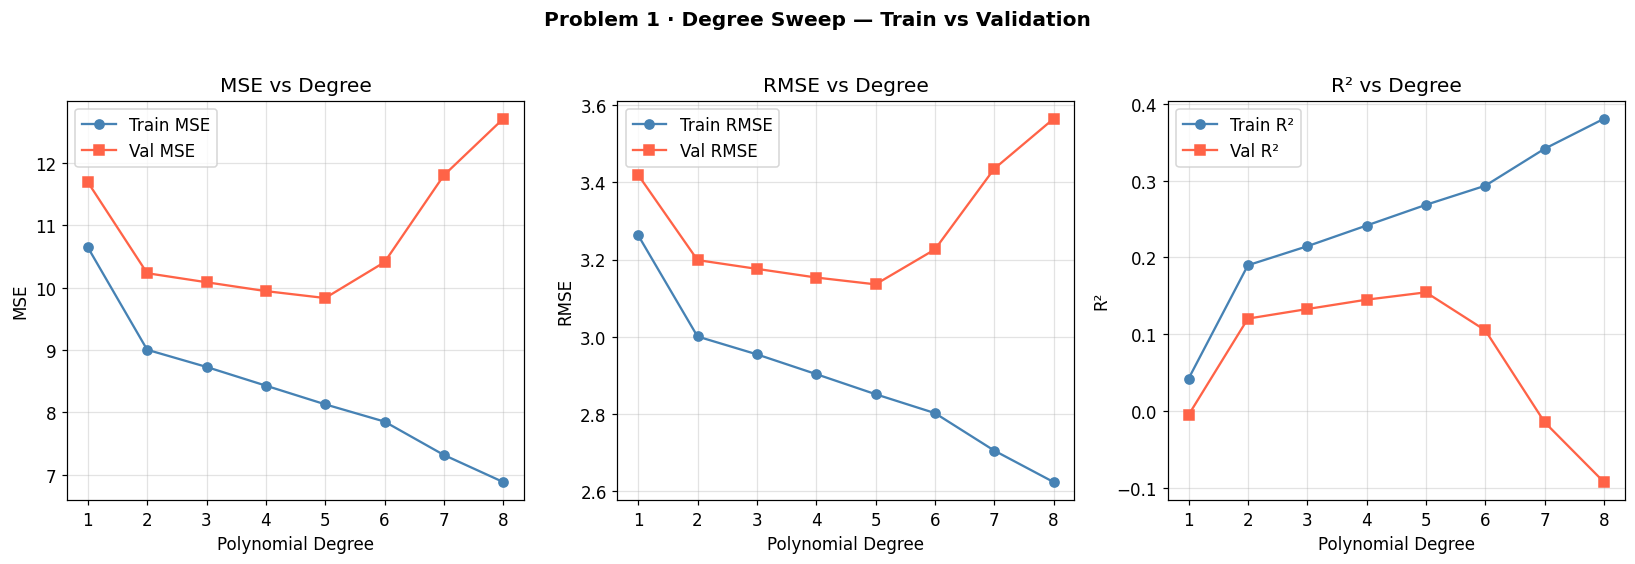

Best degree by Val MSE : 5
Best Val MSE           : 9.834306
Corresponding Val R²   : 0.154616


In [20]:
fig = plt.figure(figsize=(15, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ── MSE plot ────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.plot(degrees, train_mse,  'o-', label='Train MSE',  color='steelblue')
ax1.plot(degrees, val_mse,    's-', label='Val MSE',    color='tomato')
ax1.set_xlabel('Polynomial Degree')
ax1.set_ylabel('MSE')
ax1.set_title('MSE vs Degree')
ax1.set_xticks(degrees)
ax1.legend()

# ── RMSE plot ───────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.plot(degrees, train_rmse, 'o-', label='Train RMSE', color='steelblue')
ax2.plot(degrees, val_rmse,   's-', label='Val RMSE',   color='tomato')
ax2.set_xlabel('Polynomial Degree')
ax2.set_ylabel('RMSE')
ax2.set_title('RMSE vs Degree')
ax2.set_xticks(degrees)
ax2.legend()

# ── R² plot ─────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
ax3.plot(degrees, train_r2,   'o-', label='Train R²',   color='steelblue')
ax3.plot(degrees, val_r2,     's-', label='Val R²',     color='tomato')
ax3.set_xlabel('Polynomial Degree')
ax3.set_ylabel('R²')
ax3.set_title('R² vs Degree')
ax3.set_xticks(degrees)
ax3.legend()

plt.suptitle('Problem 1 · Degree Sweep — Train vs Validation', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Highlight best val MSE degree
best_deg = degrees[int(np.argmin(val_mse))]
print(f"Best degree by Val MSE : {best_deg}")
print(f"Best Val MSE           : {min(val_mse):.6f}")
print(f"Corresponding Val R²   : {val_r2[degrees.index(best_deg)]:.6f}")

---
## 4 · Train Final Model at Chosen Degree
Change `CHOSEN_DEGREE` below. The assignment says **degree 3** is optimal for var1.

In [21]:
# ── ★ Change this to experiment ★ ───────────────────────────────────────────
CHOSEN_DEGREE = M.DEGREE   # defaults to 3 (set in model.py)
# ────────────────────────────────────────────────────────────────────────────

w, powers, train_metrics, val_metrics = T.train_model(
    X_train, y_train, X_val, y_val,
    degree       = CHOSEN_DEGREE,
    feature_names = feature_names,
    verbose      = True,
)


-- Degree 3 ------------------------------
  Num terms : 20
[Train (deg=3)] MSE=8.730240  RMSE=2.954698  R²=0.214620  MAE=2.341573
[Val   (deg=3)] MSE=10.087348  RMSE=3.176059  R²=0.132863  MAE=2.607828

  Top-5 weights by |magnitude|:
    1. x2·x3                 w = -2.5889
    2. 1                     w = +1.9715
    3. x2^3                  w = -1.6675
    4. x1·x2^2               w = +1.0631
    5. x3^2                  w = -0.9303


---
## 5 · Residual Analysis

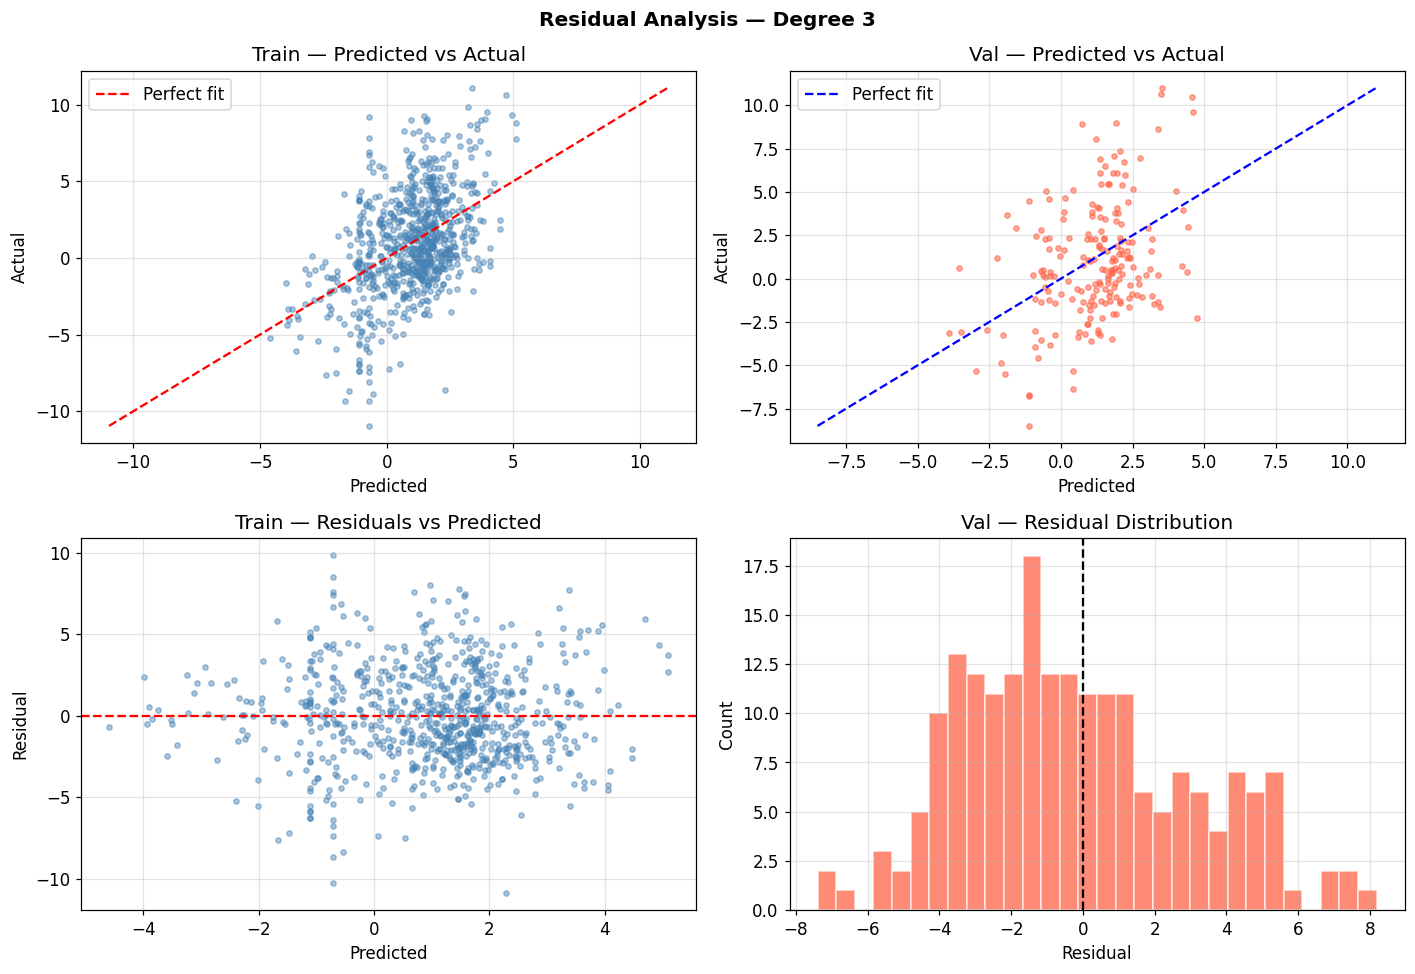

In [22]:
Phi_train, _ = M.expand_features(X_train, degree=CHOSEN_DEGREE)
Phi_val,   _ = M.expand_features(X_val,   degree=CHOSEN_DEGREE)

y_pred_train = M.predict(Phi_train, w)
y_pred_val   = M.predict(Phi_val,   w)

res_train = y_train - y_pred_train
res_val   = y_val   - y_pred_val

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Predicted vs Actual (train) ──────────────────────────────────────────────
axes[0, 0].scatter(y_pred_train, y_train, s=12, alpha=0.45, color='steelblue')
lims = [min(y_train.min(), y_pred_train.min()), max(y_train.max(), y_pred_train.max())]
axes[0, 0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
axes[0, 0].set_xlabel('Predicted'); axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_title('Train — Predicted vs Actual')
axes[0, 0].legend()

# ── Predicted vs Actual (val) ────────────────────────────────────────────────
axes[0, 1].scatter(y_pred_val, y_val, s=12, alpha=0.55, color='tomato')
lims = [min(y_val.min(), y_pred_val.min()), max(y_val.max(), y_pred_val.max())]
axes[0, 1].plot(lims, lims, 'b--', linewidth=1.5, label='Perfect fit')
axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_title('Val — Predicted vs Actual')
axes[0, 1].legend()

# ── Residuals vs Predicted (train) ──────────────────────────────────────────
axes[1, 0].scatter(y_pred_train, res_train, s=12, alpha=0.45, color='steelblue')
axes[1, 0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Predicted'); axes[1, 0].set_ylabel('Residual')
axes[1, 0].set_title('Train — Residuals vs Predicted')

# ── Residual histogram (val) ─────────────────────────────────────────────────
axes[1, 1].hist(res_val, bins=30, color='tomato', alpha=0.75, edgecolor='white')
axes[1, 1].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[1, 1].set_xlabel('Residual'); axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Val — Residual Distribution')

plt.suptitle(f'Residual Analysis — Degree {CHOSEN_DEGREE}', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 · Coefficient Inspection

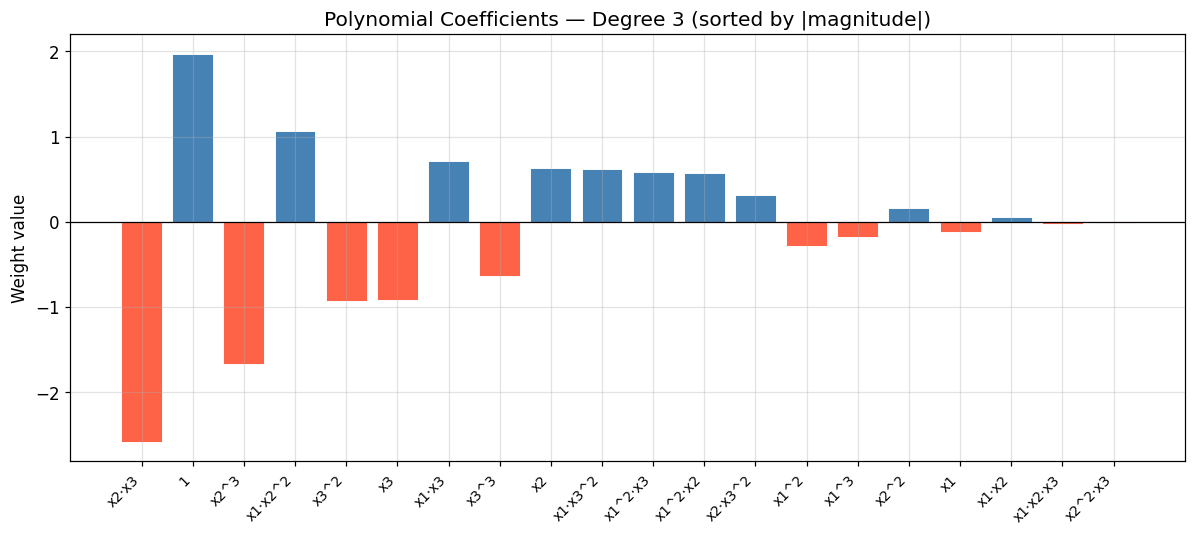


Full coefficient table:
Term                             Weight
----------------------------------------
x2·x3                         -2.588910
1                             +1.971530
x2^3                          -1.667545
x1·x2^2                       +1.063124
x3^2                          -0.930272
x3                            -0.924410
x1·x3                         +0.714649
x3^3                          -0.634314
x2                            +0.631687
x1·x3^2                       +0.615439
x1^2·x3                       +0.587748
x1^2·x2                       +0.572114
x2·x3^2                       +0.312007
x1^2                          -0.280154
x1^3                          -0.182128
x2^2                          +0.157104
x1                            -0.122230
x1·x2                         +0.053048
x1·x2·x3                      -0.029293
x2^2·x3                       -0.020051


In [23]:
labels = M.get_term_labels(feature_names, powers)

order = np.argsort(np.abs(w))[::-1]
sorted_labels = [labels[i] for i in order]
sorted_w      = w[order]

fig, ax = plt.subplots(figsize=(max(8, len(w) * 0.55), 5))
colors = ['steelblue' if v >= 0 else 'tomato' for v in sorted_w]
ax.bar(range(len(sorted_w)), sorted_w, color=colors, edgecolor='white', linewidth=0.6)
ax.set_xticks(range(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Weight value')
ax.set_title(f'Polynomial Coefficients — Degree {CHOSEN_DEGREE} (sorted by |magnitude|)')
plt.tight_layout()
plt.show()

print("\nFull coefficient table:")
print(f"{'Term':25s}  {'Weight':>12s}")
print("-" * 40)
for lbl, wi in zip(sorted_labels, sorted_w):
    print(f"{lbl:25s}  {wi:+12.6f}")

---
## 7 · Generate Test Predictions & Save CSV

[predict] Saved 1000 predictions -> ../../IMT2024045_pred_var1.csv
[predict] y_pred  min=-4.9261  max=5.1004  mean=0.7641


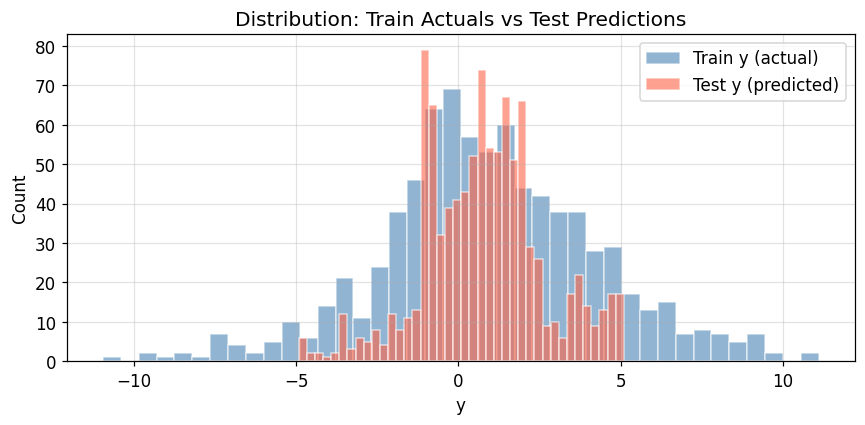

In [24]:
y_pred_test = P.generate_predictions(
    X_test,
    w,
    degree     = CHOSEN_DEGREE,
    output_csv = P.OUTPUT_CSV,
    save       = True,
)

# Quick sanity: distribution of test predictions vs train targets
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(y_train,      bins=40, alpha=0.6, label='Train y (actual)',   color='steelblue', edgecolor='white')
ax.hist(y_pred_test,  bins=40, alpha=0.6, label='Test y (predicted)', color='tomato',    edgecolor='white')
ax.set_xlabel('y')
ax.set_ylabel('Count')
ax.set_title('Distribution: Train Actuals vs Test Predictions')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8 · Final Summary

In [25]:
print("╔══════════════════════════════════════════════════════╗")
print("║          PROBLEM 1 — FINAL SUMMARY (var1)           ║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Features used  : {', '.join(feature_names):<34s}║")
print(f"║  Degree         : {CHOSEN_DEGREE:<34d}║")
print(f"║  Num terms      : {len(powers):<34d}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Train MSE      : {train_metrics['mse']:<34.6f}║")
print(f"║  Train R²       : {train_metrics['r2']:<34.6f}║")
print(f"║  Val   MSE      : {val_metrics['mse']:<34.6f}║")
print(f"║  Val   R²       : {val_metrics['r2']:<34.6f}║")
print("╠══════════════════════════════════════════════════════╣")
print(f"║  Predictions    : {P.OUTPUT_CSV:<34s}║")
print("╚══════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════╗
║          PROBLEM 1 — FINAL SUMMARY (var1)           ║
╠══════════════════════════════════════════════════════╣
║  Features used  : x1, x2, x3                        ║
║  Degree         : 3                                 ║
║  Num terms      : 20                                ║
╠══════════════════════════════════════════════════════╣
║  Train MSE      : 8.730240                          ║
║  Train R²       : 0.214620                          ║
║  Val   MSE      : 10.087348                         ║
║  Val   R²       : 0.132863                          ║
╠══════════════════════════════════════════════════════╣
║  Predictions    : ../../IMT2024045_pred_var1.csv    ║
╚══════════════════════════════════════════════════════╝
